# 🎵 Spotify Listening History — Personal Data Analysis

> **By Nyan Lin Tun** · Data source: Spotify Extended Streaming History (Jan 2025 – Jan 2026)

This project analyses over **80,000 personal Spotify streams** to uncover patterns in listening behaviour, artist loyalty, time-of-day habits, and music discovery retention.

**Skills demonstrated:** Python · pandas · Plotly · data cleaning · cohort analysis · behavioural analytics

---

## Table of Contents
1. [Setup & Data Loading](#1)
2. [Overview Stats](#2)
3. [Listening Habits & Time Patterns](#3)
4. [Top Artists & Tracks](#4)
5. [Listening Behaviour (Skip Rate, Sessions, Loyalty)](#5)
6. [Music Discovery & Cohort Retention](#6)
7. [Artist Deep Dives](#7)
8. [Key Findings](#8)

---
## 1. Setup & Data Loading <a id='1'></a>

In [3]:
import json
import glob
import os
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Spotify colour palette ──
SPOTIFY_GREEN   = '#1DB954'
SPOTIFY_BLACK   = '#191414'
SPOTIFY_WHITE   = '#FFFFFF'
PALETTE = [SPOTIFY_GREEN, '#5c67f2', '#ff6b35', '#f2c94c', '#9b59b6', '#e74c3c']

PLOTLY_TEMPLATE = dict(
    layout=dict(
        paper_bgcolor='#191414',
        plot_bgcolor='#1e1e1e',
        font=dict(color='#FFFFFF', family='Arial'),
        title=dict(font=dict(size=18, color='#1DB954')),
        xaxis=dict(gridcolor='#2a2a2a', zerolinecolor='#2a2a2a'),
        yaxis=dict(gridcolor='#2a2a2a', zerolinecolor='#2a2a2a'),
    )
)

print('Libraries loaded ✓')

Libraries loaded ✓


In [5]:
# ── CHANGE this path to wherever your JSON files live ──
BASE_PATH = '/Users/nyanlintun/Downloads/Spotify Account Data'

dfs = []
for i in range(9):  # StreamingHistory_music_0 … _8
    path = os.path.join(BASE_PATH, f'StreamingHistory_music_{i}.json')
    with open(path, 'r') as f:
        dfs.append(pd.DataFrame(json.load(f)))

raw = pd.concat(dfs, ignore_index=True)
print(f'Raw rows loaded: {len(raw):,}')
raw.head(3)

Raw rows loaded: 80,133


,endTime,artistName,trackName,msPlayed
0,2025-01-11 00:01,Artie J,I Want Her Too,172833
1,2025-01-11 00:04,Nobu Woods,INCOMPLETE,145920
2,2025-01-11 00:07,Avi Roy,breathe,167339


In [7]:
# ── Clean & enrich ──
df = raw.copy()
df['endTime']      = pd.to_datetime(df['endTime'])
df                 = df.sort_values('endTime').reset_index(drop=True)
df['hours_played'] = df['msPlayed'] / (1000 * 60 * 60)
df['date']         = df['endTime'].dt.date
df['year']         = df['endTime'].dt.year
df['month']        = df['endTime'].dt.to_period('M')
df['month_dt']     = df['endTime'].dt.to_period('M').dt.to_timestamp()
df['day_of_week']  = df['endTime'].dt.day_name()
df['hour']         = df['endTime'].dt.hour
df['period']       = df['hour'].apply(lambda h: 'Night (10 pm – 4 am)' if (h >= 22 or h <= 4) else 'Day')

# Sessions: gap > 30 min = new session
df['gap_min']    = df['endTime'].diff().dt.total_seconds() / 60
df['session_id'] = (df['gap_min'] > 30).cumsum()

# First-play cohort for retention analysis
first_play   = df.groupby(['artistName', 'trackName'])['endTime'].min().reset_index(name='first_play')
df           = df.merge(first_play, on=['artistName', 'trackName'])
df['cohort_month']             = df['first_play'].dt.to_period('M')
df['listen_month']             = df['endTime'].dt.to_period('M')
df['months_since_discovery']   = (df['listen_month'] - df['cohort_month']).apply(lambda x: x.n)

print(f'Clean rows: {len(df):,}')
print(f'Date range: {df["endTime"].min().date()} → {df["endTime"].max().date()}')
print(f'Unique artists: {df["artistName"].nunique():,}  |  Unique tracks: {df["trackName"].nunique():,}')

Clean rows: 80,133
Date range: 2025-01-11 → 2026-01-11
Unique artists: 972  |  Unique tracks: 4,695


---
## 2. Overview Stats <a id='2'></a>

In [10]:
total_hours   = df['hours_played'].sum()
total_days    = total_hours / 24
skip_rate     = (df['msPlayed'] < 60_000).mean()
repeat_ratio  = (df.groupby(['artistName', 'trackName']).size() > 1).mean()
session_stats = df.groupby('session_id')['hours_played'].sum()

print('╔══════════════════════════════════════════╗')
print('║          YOUR SPOTIFY IN NUMBERS         ║')
print('╠══════════════════════════════════════════╣')
print(f'║  Total streams:        {len(df):>10,}      ║')
print(f'║  Total hours:          {total_hours:>10,.0f}      ║')
print(f'║  Total days:           {total_days:>10.1f}      ║')
print(f'║  Unique artists:       {df["artistName"].nunique():>10,}      ║')
print(f'║  Unique tracks:        {df["trackName"].nunique():>10,}      ║')
print(f'║  Skip rate (<60s):     {skip_rate:>9.1%}       ║')
print(f'║  Tracks replayed:      {repeat_ratio:>9.1%}       ║')
print(f'║  Avg session length:   {session_stats.mean():>7.2f}h        ║')
print('╚══════════════════════════════════════════╝')

╔══════════════════════════════════════════╗
║          YOUR SPOTIFY IN NUMBERS         ║
╠══════════════════════════════════════════╣
║  Total streams:            80,133      ║
║  Total hours:               1,781      ║
║  Total days:                 74.2      ║
║  Unique artists:              972      ║
║  Unique tracks:             4,695      ║
║  Skip rate (<60s):         58.7%       ║
║  Tracks replayed:          63.6%       ║
║  Avg session length:      1.10h        ║
╚══════════════════════════════════════════╝


---
## 3. Listening Habits & Time Patterns <a id='3'></a>

When do I listen? How has it changed over time?

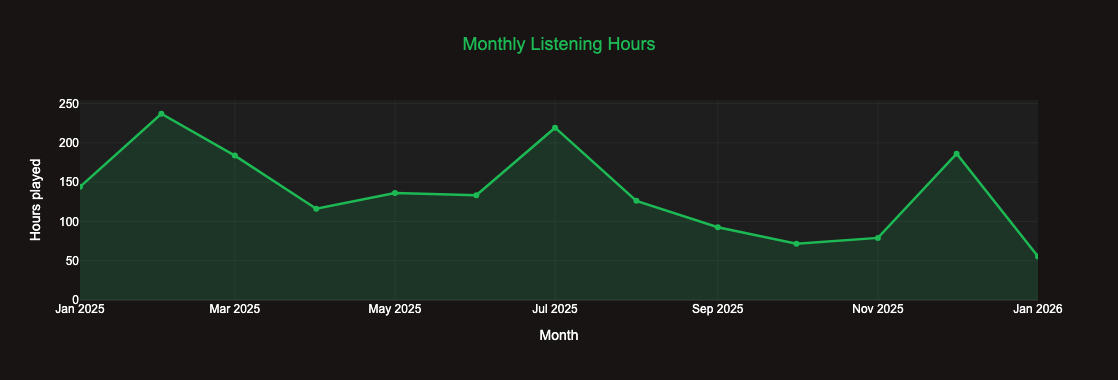

In [26]:
# ── Monthly listening volume ──
monthly = df.groupby('month_dt')['hours_played'].sum().reset_index()
monthly.columns = ['month', 'hours']

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly['month'],
    y=monthly['hours'],
    mode='lines+markers',
    line=dict(color=SPOTIFY_GREEN, width=2.5),
    marker=dict(size=6, color=SPOTIFY_GREEN),
    fill='tozeroy',
    fillcolor='rgba(29,185,84,0.15)',
    name='Hours'
))

# Apply template FIRST
fig.update_layout(**PLOTLY_TEMPLATE['layout'])

# THEN override safely (no conflicts)
fig.update_layout(
    title=dict(text='Monthly Listening Hours', x=0.5),
    xaxis_title='Month',
    yaxis_title='Hours played',
    height=380
)

fig.show()

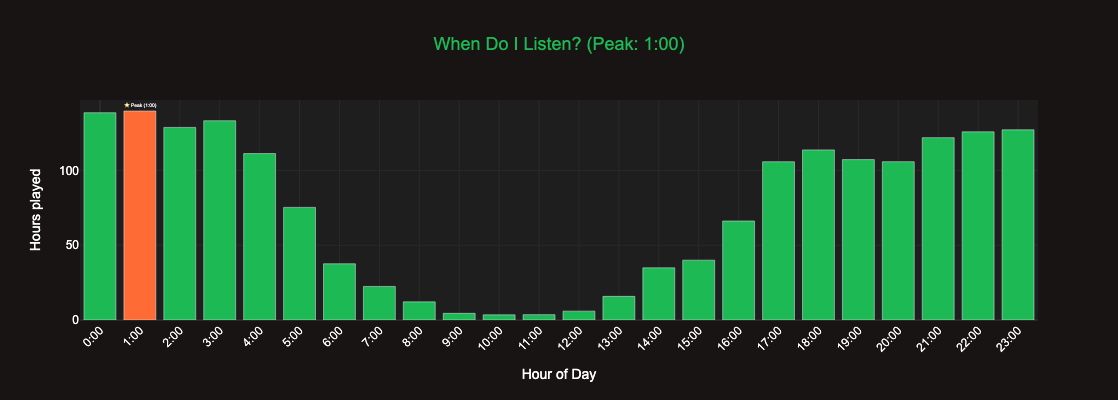

In [28]:
# ── Hour-of-day bar chart ──
hourly = df.groupby('hour')['hours_played'].sum().reset_index()
hourly.columns = ['hour', 'hours']

peak_hour = hourly.loc[hourly['hours'].idxmax(), 'hour']

hourly['color'] = hourly['hour'].apply(
    lambda h: '#ff6b35' if h == peak_hour else SPOTIFY_GREEN
)

fig = go.Figure(go.Bar(
    x=hourly['hour'],
    y=hourly['hours'],
    marker_color=hourly['color'],
    text=hourly['hour'].apply(
        lambda h: f'⭐ Peak ({h}:00)' if h == peak_hour else ''
    ),
    textposition='outside',
))

# 1️⃣ Apply template first
fig.update_layout(**PLOTLY_TEMPLATE['layout'])

# 2️⃣ Then customize (no conflicts)
fig.update_layout(
    title=dict(text=f'When Do I Listen? (Peak: {peak_hour}:00)', x=0.5),
    xaxis_title='Hour of Day',
    yaxis_title='Hours played',
    xaxis=dict(
        tickvals=list(range(24)),
        ticktext=[f'{h}:00' for h in range(24)],
        tickangle=-45,
        gridcolor='#2a2a2a'
    ),
    yaxis=dict(gridcolor='#2a2a2a'),
    height=400
)

fig.show()

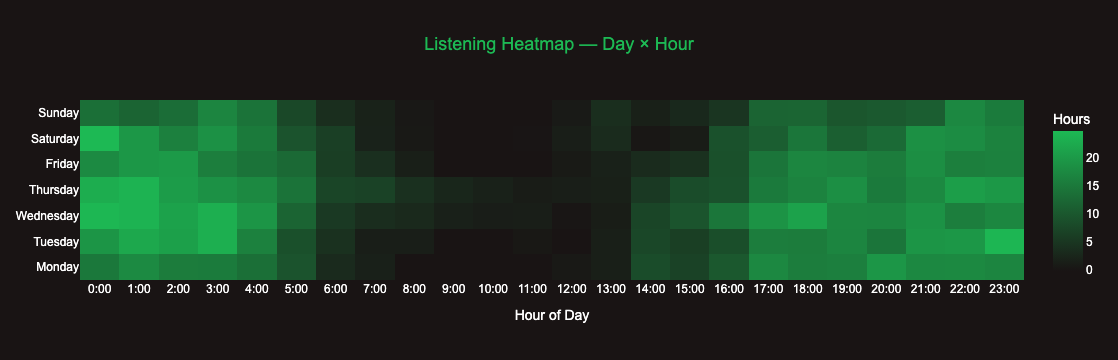

In [30]:
# ── Day × Hour heatmap ──
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

hm = (
    df.groupby(['day_of_week','hour'])['hours_played']
    .sum()
    .unstack(fill_value=0)
    .reindex(day_order)
)

fig = go.Figure(go.Heatmap(
    z=hm.values,
    x=[f'{h}:00' for h in range(24)],
    y=day_order,
    colorscale=[[0,'#191414'],[1,SPOTIFY_GREEN]],
    colorbar=dict(title='Hours'),
))

# 1️⃣ Apply template first
fig.update_layout(**PLOTLY_TEMPLATE['layout'])

# 2️⃣ Then customize safely
fig.update_layout(
    title=dict(text='Listening Heatmap — Day × Hour', x=0.5),
    xaxis_title='Hour of Day',
    height=360
)

fig.show()

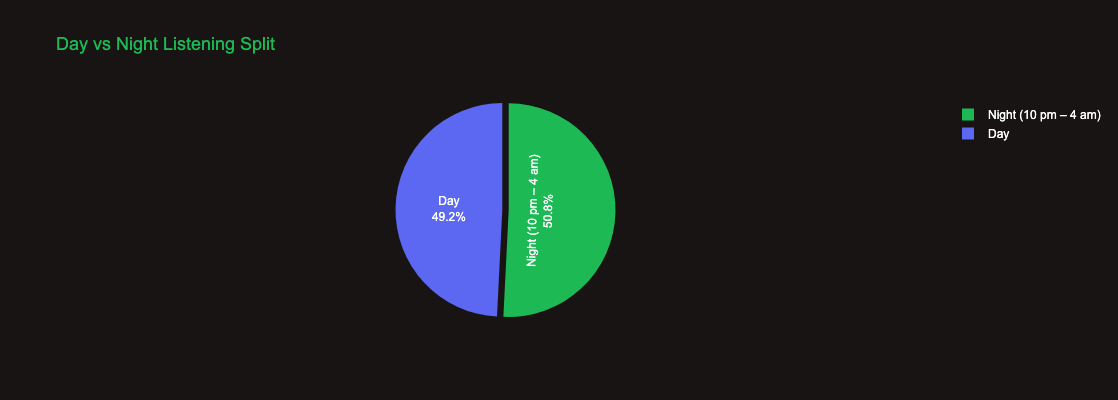

              period      hours       pct
                 Day 876.501731 49.207262
Night (10 pm – 4 am) 904.742937 50.792738


In [18]:
# ── Day vs Night split ──
period_hours = df.groupby('period')['hours_played'].sum().reset_index()
period_hours.columns = ['period', 'hours']
period_hours['pct'] = period_hours['hours'] / period_hours['hours'].sum() * 100

fig = px.pie(
    period_hours, names='period', values='hours',
    color_discrete_sequence=[SPOTIFY_GREEN, '#5c67f2'],
    title='Day vs Night Listening Split',
)
fig.update_traces(textinfo='label+percent', pull=[0.03, 0.03])
fig.update_layout(**PLOTLY_TEMPLATE['layout'], height=400)
fig.show()

print(period_hours.to_string(index=False))

---
## 4. Top Artists & Tracks <a id='4'></a>

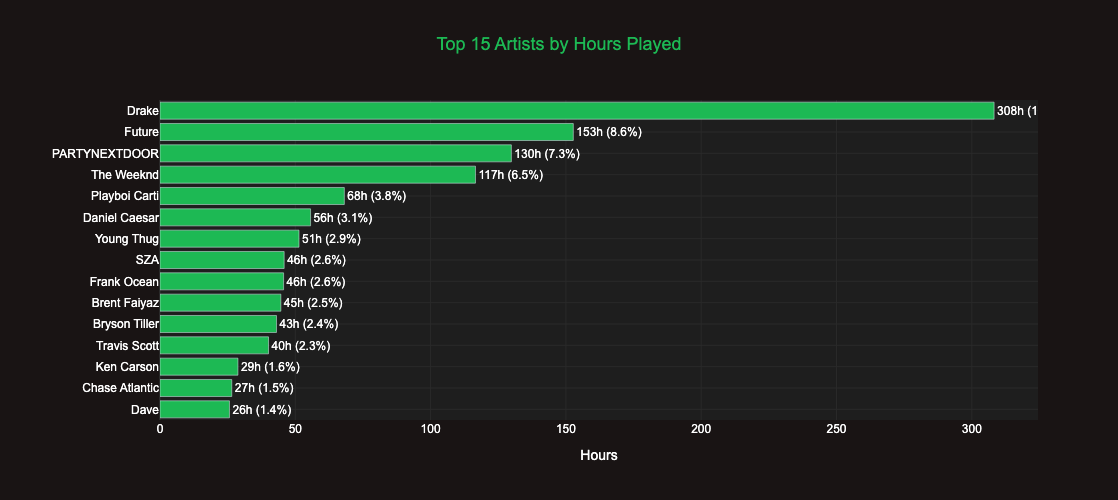

In [32]:
# ── Top 15 Artists (hours) ──
top_artists = (
    df.groupby('artistName')['hours_played']
    .sum()
    .sort_values(ascending=True)
    .tail(15)
    .reset_index()
)

top_artists.columns = ['artist', 'hours']
total_hours = df['hours_played'].sum()

top_artists['share'] = top_artists['hours'] / total_hours * 100

fig = go.Figure(go.Bar(
    x=top_artists['hours'],
    y=top_artists['artist'],
    orientation='h',
    marker_color=SPOTIFY_GREEN,
    text=top_artists.apply(
        lambda row: f"{row['hours']:.0f}h ({row['share']:.1f}%)",
        axis=1
    ),
    textposition='outside',
))

# 1️⃣ Apply template first
fig.update_layout(**PLOTLY_TEMPLATE['layout'])

# 2️⃣ Then override safely
fig.update_layout(
    title=dict(text='Top 15 Artists by Hours Played', x=0.5),
    xaxis_title='Hours',
    height=500,
    margin=dict(l=160)
)

fig.show()

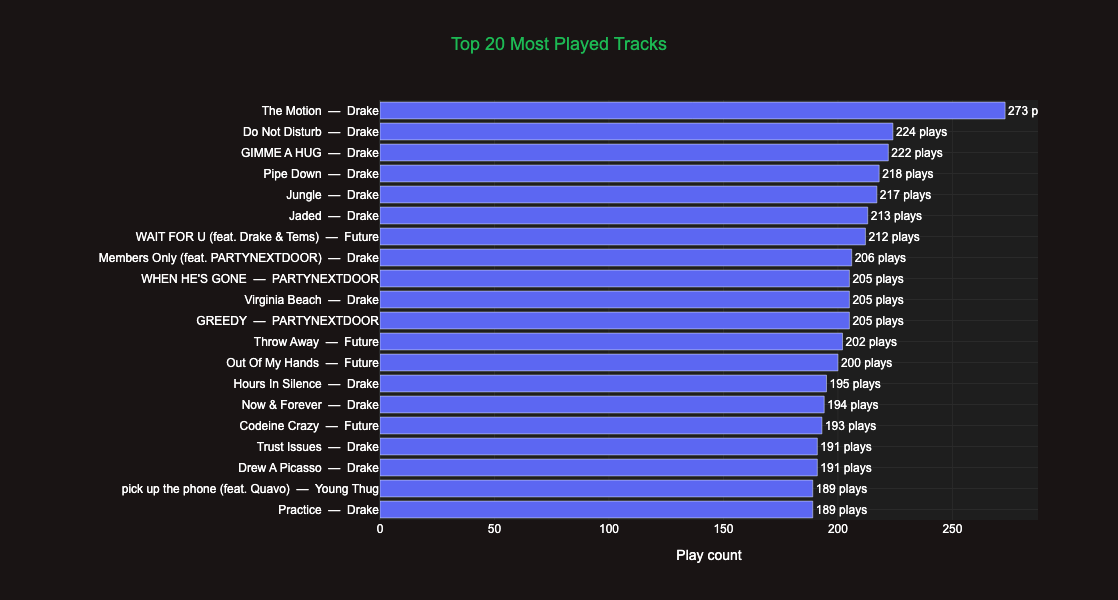

In [34]:
# ── Top 20 Tracks (play count) ──
top_tracks = (
    df.groupby(['artistName','trackName'])
    .agg(plays=('trackName','count'), hours=('hours_played','sum'))
    .reset_index()
    .sort_values('plays', ascending=True)
    .tail(20)
)
top_tracks['label'] = top_tracks['trackName'].str[:40] + '  —  ' + top_tracks['artistName']

fig = go.Figure(go.Bar(
    x=top_tracks['plays'],
    y=top_tracks['label'],
    orientation='h',
    marker_color='#5c67f2',
    text=top_tracks['plays'].astype(str) + ' plays',
    textposition='outside',
))

fig.update_layout(**PLOTLY_TEMPLATE['layout'])

fig.update_layout(
    title=dict(text='Top 20 Most Played Tracks', x=0.5),
    xaxis_title='Play count',
    height=600,
    margin=dict(l=380),
)
fig.show()

Top 10 artists account for 57.2% of total listening time.
Remaining 962 artists share the other 42.8%.



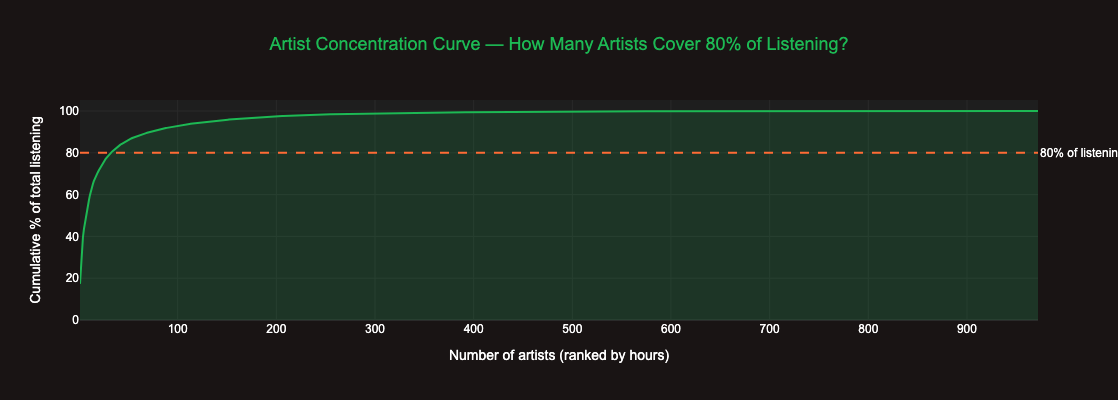

In [46]:
# ── Artist concentration (how much of total listening is top-10?) ──
all_artists = df.groupby('artistName')['hours_played'].sum().sort_values(ascending=False)
top10_share = all_artists.head(10).sum() / all_artists.sum() * 100

print(f'Top 10 artists account for {top10_share:.1f}% of total listening time.')
print(f'Remaining {len(all_artists) - 10:,} artists share the other {100 - top10_share:.1f}%.')
print()

# Cumulative concentration curve
cumulative = all_artists.cumsum() / all_artists.sum() * 100
fig = go.Figure(go.Scatter(
    x=list(range(1, len(cumulative)+1)),
    y=cumulative.values,
    mode='lines',
    line=dict(color=SPOTIFY_GREEN, width=2),
    fill='tozeroy',
    fillcolor='rgba(29,185,84,0.15)',
))
fig.add_hline(y=80, line_dash='dash', line_color='#ff6b35',
              annotation_text='80% of listening', annotation_position='right')

fig.update_layout(**PLOTLY_TEMPLATE['layout'])
                  
fig.update_layout(
    title=dict(text='Artist Concentration Curve — How Many Artists Cover 80% of Listening?', x=0.5),
    xaxis_title='Number of artists (ranked by hours)',
    yaxis_title='Cumulative % of total listening',
    height=400,
)
fig.show()

---
## 5. Listening Behaviour — Skips, Sessions & Loyalty <a id='5'></a>

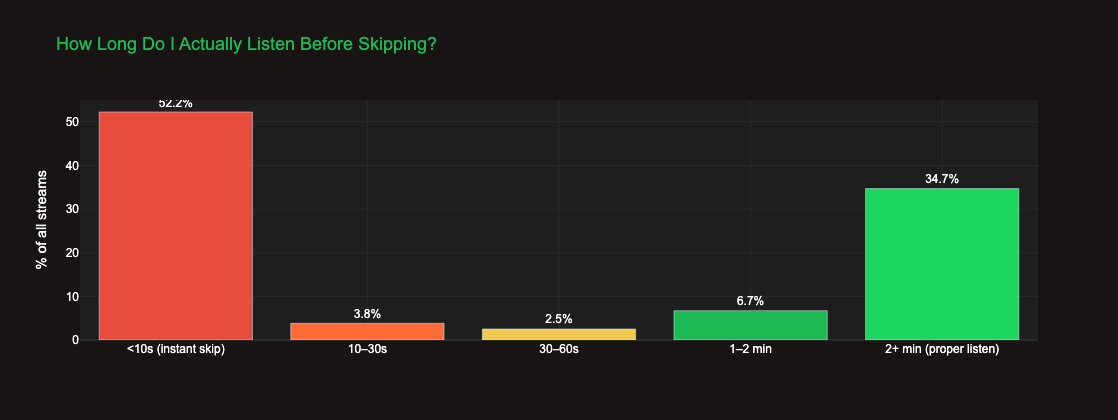

In [48]:
# ── Skip rate breakdown ──
df['listen_category'] = pd.cut(
    df['msPlayed'] / 1000,
    bins=[0, 10, 30, 60, 120, float('inf')],
    labels=['<10s (instant skip)', '10–30s', '30–60s', '1–2 min', '2+ min (proper listen)']
)
listen_dist = df['listen_category'].value_counts().sort_index().reset_index()
listen_dist.columns = ['category', 'count']
listen_dist['pct'] = listen_dist['count'] / listen_dist['count'].sum() * 100

fig = px.bar(
    listen_dist, x='category', y='pct',
    color='category',
    color_discrete_sequence=['#e74c3c','#ff6b35','#f2c94c',SPOTIFY_GREEN,'#1ed760'],
    text=listen_dist['pct'].apply(lambda p: f'{p:.1f}%'),
    title='How Long Do I Actually Listen Before Skipping?',
)
fig.update_traces(textposition='outside', showlegend=False)
fig.update_layout(
    **PLOTLY_TEMPLATE['layout'],
    xaxis_title='',
    yaxis_title='% of all streams',
    height=420,
)
fig.show()

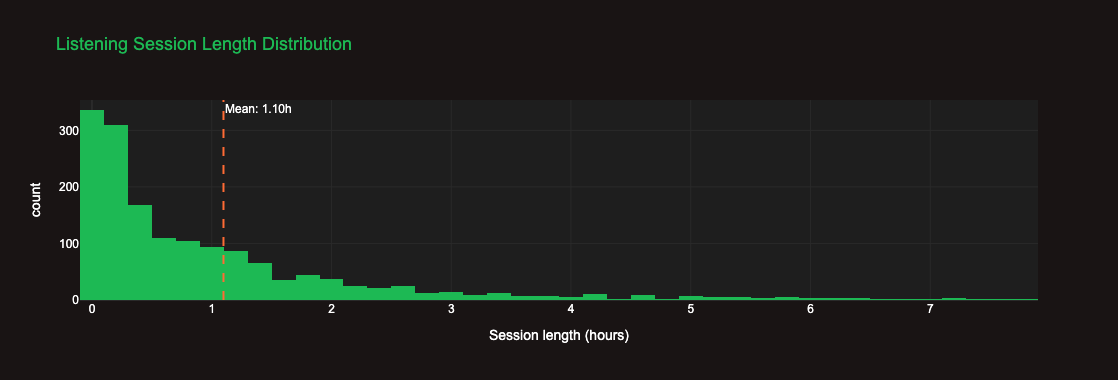

Total sessions:      1,622
Mean session length: 1.10h
Median:              0.49h
Longest session:     13.99h


In [50]:
# ── Session length distribution ──
session_lengths = df.groupby('session_id')['hours_played'].sum()
session_lengths_h = session_lengths[session_lengths < 8]  # cap at 8h for readability

fig = px.histogram(
    session_lengths_h, x=session_lengths_h.values,
    nbins=40,
    color_discrete_sequence=[SPOTIFY_GREEN],
    title='Listening Session Length Distribution',
    labels={'x': 'Session length (hours)', 'y': 'Number of sessions'},
)
fig.add_vline(
    x=session_lengths.mean(), line_dash='dash', line_color='#ff6b35',
    annotation_text=f'Mean: {session_lengths.mean():.2f}h', annotation_position='top right'
)
fig.update_layout(**PLOTLY_TEMPLATE['layout'], height=380)
fig.show()

print(f'Total sessions:      {len(session_lengths):,}')
print(f'Mean session length: {session_lengths.mean():.2f}h')
print(f'Median:              {session_lengths.median():.2f}h')
print(f'Longest session:     {session_lengths.max():.2f}h')

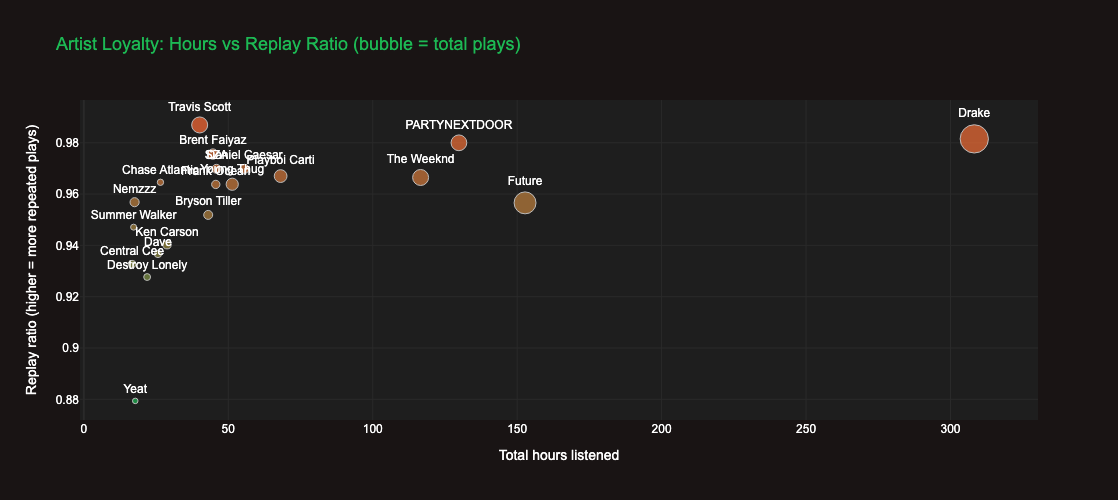

In [52]:
# ── Artist loyalty: repeat-play ratio per artist ──
artist_loyalty = (
    df.groupby('artistName')
    .agg(total_plays=('trackName','count'), unique_tracks=('trackName','nunique'), hours=('hours_played','sum'))
    .query('total_plays >= 30')
    .assign(replay_ratio=lambda x: 1 - x['unique_tracks'] / x['total_plays'])
    .sort_values('hours', ascending=False)
    .head(20)
    .reset_index()
)

fig = px.scatter(
    artist_loyalty, x='hours', y='replay_ratio',
    size='total_plays', text='artistName',
    color='replay_ratio',
    color_continuous_scale=[[0,SPOTIFY_GREEN],[1,'#ff6b35']],
    title='Artist Loyalty: Hours vs Replay Ratio (bubble = total plays)',
    labels={'hours': 'Total hours listened', 'replay_ratio': 'Replay ratio (higher = more repeated plays)'},
)
fig.update_traces(textposition='top center', marker=dict(line=dict(width=1, color='white')))
fig.update_layout(
    **PLOTLY_TEMPLATE['layout'],
    height=500,
    coloraxis_showscale=False,
)
fig.show()

---
## 6. Music Discovery & Cohort Retention <a id='6'></a>

When I discover new tracks, do I keep listening to them or drop them after a few days?

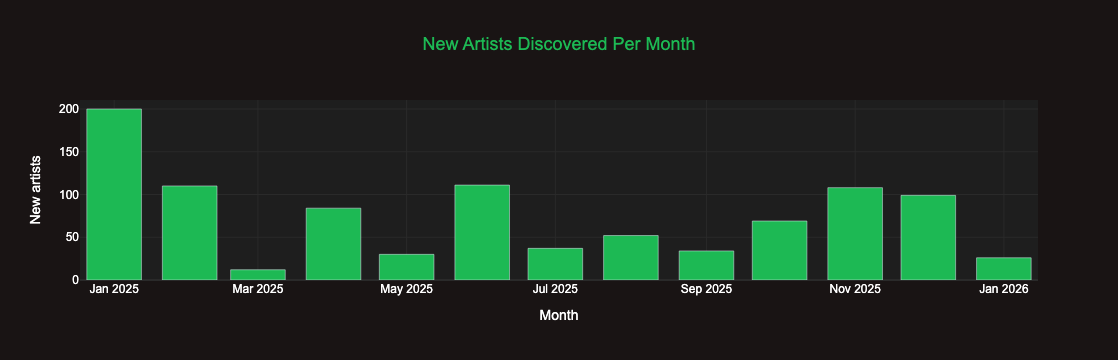

In [62]:
# ── Monthly new artists discovered ──
first_artist_play = df.groupby('artistName')['endTime'].min().dt.to_period('M').dt.to_timestamp()
new_artists_per_month = first_artist_play.value_counts().sort_index().reset_index()
new_artists_per_month.columns = ['month', 'new_artists']

fig = go.Figure(go.Bar(
    x=new_artists_per_month['month'],
    y=new_artists_per_month['new_artists'],
    marker_color=SPOTIFY_GREEN,
))
fig.update_layout(**PLOTLY_TEMPLATE['layout'])
fig.update_layout(
    title=dict(text='New Artists Discovered Per Month', x=0.5),
    
    xaxis_title='Month',
    yaxis_title='New artists',
    height=360,
)
fig.show()

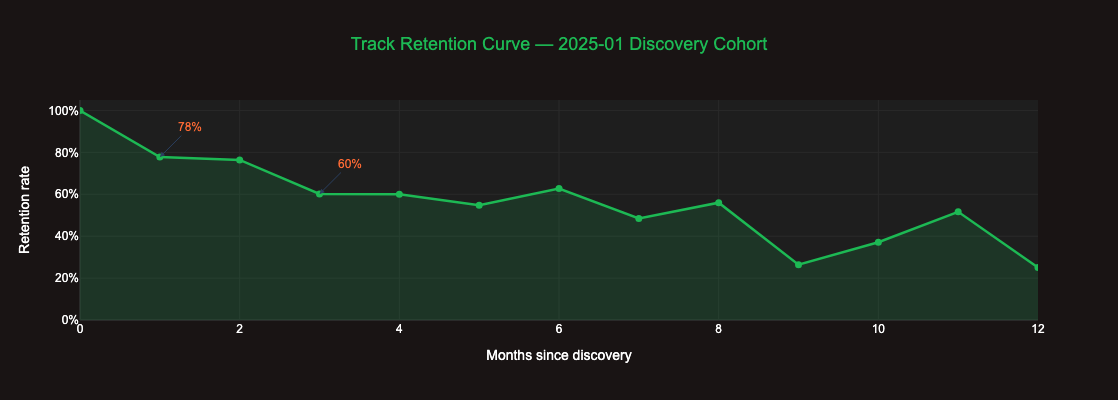

 months_since_discovery  num_tracks  retention_rate
                      0         984        1.000000
                      1         765        0.777439
                      2         752        0.764228
                      3         592        0.601626
                      4         591        0.600610
                      5         539        0.547764
                      6         617        0.627033
                      7         477        0.484756
                      8         551        0.559959
                      9         260        0.264228
                     10         365        0.370935
                     11         508        0.516260
                     12         247        0.251016


In [72]:
# ── Cohort retention: what % of tracks discovered in month X do I still play N months later? ──
cohort_retention = (
    df.groupby(['cohort_month','months_since_discovery'])['trackName']
    .nunique()
    .reset_index(name='num_tracks')
)
cohort_sizes = (
    cohort_retention[cohort_retention['months_since_discovery'] == 0]
    .set_index('cohort_month')['num_tracks']
)
cohort_retention['retention_rate'] = cohort_retention.apply(
    lambda row: row['num_tracks'] / cohort_sizes[row['cohort_month']]
    if row['cohort_month'] in cohort_sizes else None,
    axis=1
)

# Plot the most populated cohort (usually the earliest one)
largest_cohort = cohort_sizes.idxmax()
example = cohort_retention[cohort_retention['cohort_month'] == largest_cohort].dropna()

fig = go.Figure(go.Scatter(
    x=example['months_since_discovery'],
    y=example['retention_rate'],
    mode='lines+markers',
    line=dict(color=SPOTIFY_GREEN, width=2.5),
    marker=dict(size=7, color=SPOTIFY_GREEN),
    fill='tozeroy',
    fillcolor='rgba(29,185,84,0.15)',
))
fig.update_layout(**PLOTLY_TEMPLATE['layout'])
fig.update_layout(
    title=dict(
        text=f'Track Retention Curve — {largest_cohort} Discovery Cohort',
        x=0.5
    ),
    xaxis_title='Months since discovery',
    yaxis_title='Retention rate',
    yaxis=dict(tickformat='.0%', gridcolor='#2a2a2a', range=[0,1.05]),
    height=400,
)
# Annotate key points
for mo, label in [(1,'1 month'), (3,'3 months')]:
    row = example[example['months_since_discovery'] == mo]
    if not row.empty:
        r = row['retention_rate'].values[0]
        fig.add_annotation(x=mo, y=r, text=f'{r:.0%}', showarrow=True, arrowhead=2,
                           ax=30, ay=-30, font=dict(color='#ff6b35', size=12))
fig.show()

print(example[['months_since_discovery','num_tracks','retention_rate']].to_string(index=False))

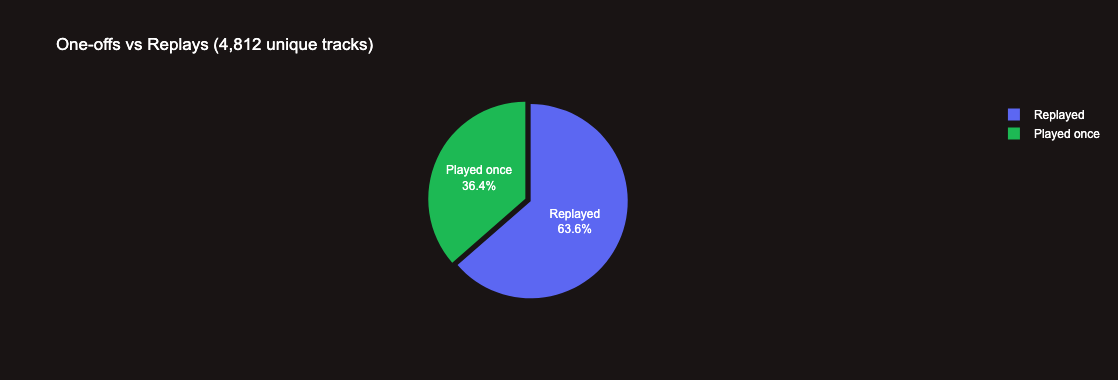


Conclusion: 63.6% of discovered tracks get replayed — I'm a comfort listener with some exploration.


In [82]:
# ── Repeat vs one-off tracks ──
track_counts = df.groupby(['artistName','trackName']).size()
one_off  = (track_counts == 1).sum()
repeated = (track_counts > 1).sum()
total_tracks = len(track_counts)

fig = go.Figure(go.Pie(
    labels=['Played once', 'Replayed'],
    values=[one_off, repeated],
    marker_colors=[SPOTIFY_GREEN, '#5c67f2'],
    pull=[0.03, 0.03],
    textinfo='label+percent',
))
fig.update_layout(**PLOTLY_TEMPLATE['layout'])
fig.update_layout(
    title=f'One-offs vs Replays ({total_tracks:,} unique tracks)',
    height=380,
)
fig.show()

print(f"\nConclusion: {repeated/total_tracks:.1%} of discovered tracks get replayed — I'm a comfort listener with some exploration.")

---
## 7. Artist Deep Dives <a id='7'></a>

### 7a. Drake — #1 Artist (17.3% of all listening)

Drake: 308h total  |  17.3% of all listening


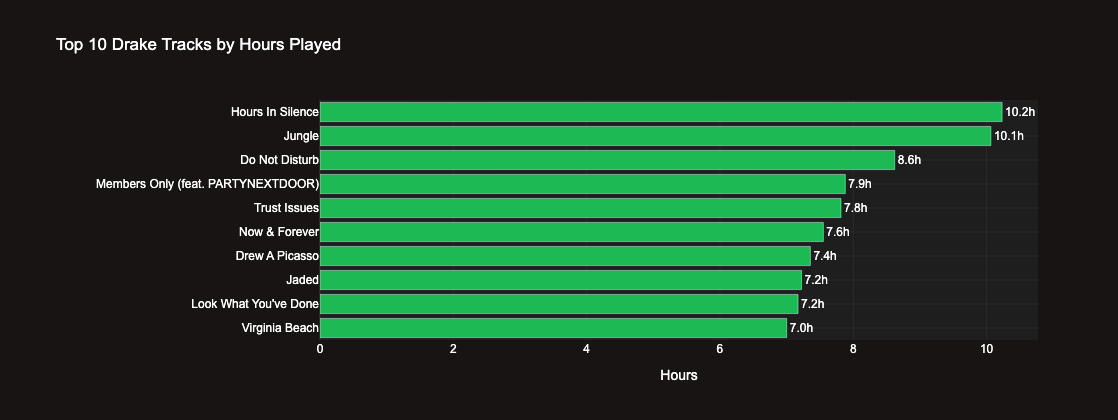

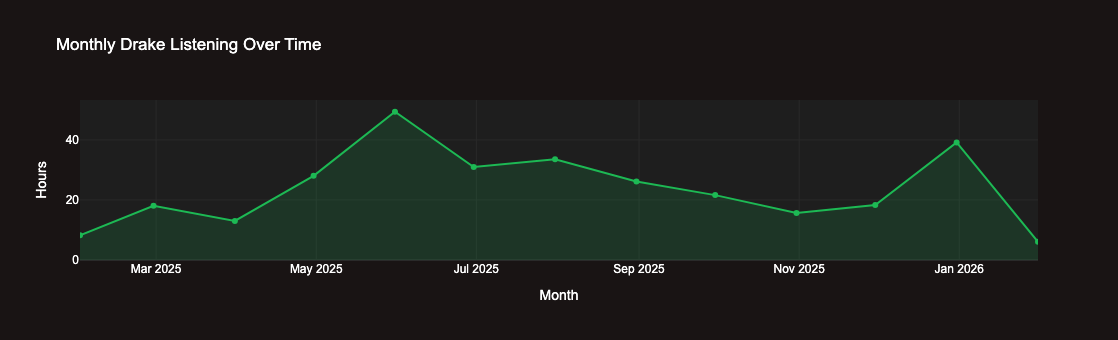

In [84]:
drake_df = df[df['artistName'] == 'Drake'].copy()
drake_share = drake_df['hours_played'].sum() / df['hours_played'].sum()
print(f"Drake: {drake_df['hours_played'].sum():.0f}h total  |  {drake_share:.1%} of all listening")

# Top tracks
top_drake = (
    drake_df.groupby('trackName')['hours_played']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
    .reset_index()
)
top_drake.columns = ['track', 'hours']

fig = go.Figure(go.Bar(
    x=top_drake['hours'], y=top_drake['track'],
    orientation='h',
    marker_color=SPOTIFY_GREEN,
    text=top_drake['hours'].apply(lambda h: f'{h:.1f}h'),
    textposition='outside',
))
fig.update_layout(**PLOTLY_TEMPLATE['layout'])
fig.update_layout(
    title='Top 10 Drake Tracks by Hours Played',
    xaxis_title='Hours',
    height=420,
    margin=dict(l=320),
)
fig.show()

# Monthly trend
drake_monthly = (
    drake_df.set_index('endTime')
    .resample('ME')['hours_played']
    .sum()
    .reset_index()
)
fig2 = go.Figure(go.Scatter(
    x=drake_monthly['endTime'], y=drake_monthly['hours_played'],
    mode='lines+markers',
    line=dict(color=SPOTIFY_GREEN, width=2),
    fill='tozeroy', fillcolor='rgba(29,185,84,0.15)',
))
fig2.update_layout(**PLOTLY_TEMPLATE['layout'])
fig2.update_layout(
    title='Monthly Drake Listening Over Time',
    xaxis_title='Month', yaxis_title='Hours',
    height=340,
)
fig2.show()

### 7b. Dave — New Discovery (June 2025)

Dave: 26h total  |  1.4% of all listening
First listen: 2025-06-26  |  Latest: 2026-01-11


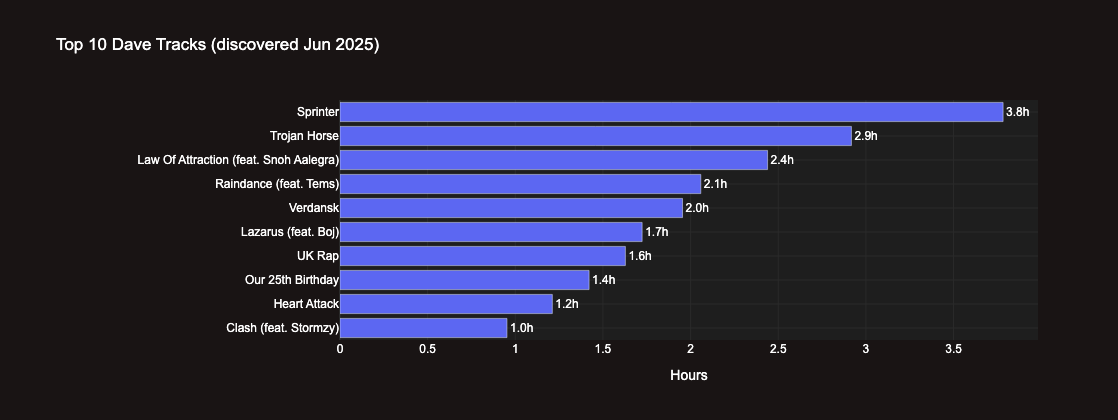

In [86]:
dave_df = df[df['artistName'].str.upper() == 'DAVE'].copy()
dave_share = dave_df['hours_played'].sum() / df['hours_played'].sum()
print(f"Dave: {dave_df['hours_played'].sum():.0f}h total  |  {dave_share:.1%} of all listening")
print(f"First listen: {dave_df['endTime'].min().date()}  |  Latest: {dave_df['endTime'].max().date()}")

# Top tracks
top_dave = (
    dave_df.groupby('trackName')['hours_played']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
    .reset_index()
)
top_dave.columns = ['track', 'hours']

fig = go.Figure(go.Bar(
    x=top_dave['hours'], y=top_dave['track'],
    orientation='h',
    marker_color='#5c67f2',
    text=top_dave['hours'].apply(lambda h: f'{h:.1f}h'),
    textposition='outside',
))
fig.update_layout(**PLOTLY_TEMPLATE['layout'])
fig.update_layout(
    title='Top 10 Dave Tracks (discovered Jun 2025)',
    xaxis_title='Hours',
    height=420,
    margin=dict(l=340),
)
fig.show()

---
## 8. Key Findings <a id='8'></a>

| Finding | Detail |
|---|---|
| **Heavy listener** | ~1,800+ hours of music across the year |
| **Night owl** | Peak listening hour is late evening; significant night listening (10 pm – 4 am) |
| **Comfort listener** | ~64% of discovered tracks get replayed; top 10 artists = 57%+ of time |
| **High skip rate** | ~59% of streams are under 60 seconds — very selective |
| **Drake dominant** | Drake alone = 17% of all listening (~308 hours) |
| **Rapid new-artist adoption** | Dave (discovered Jun 2025): already 25+ hours within months |
| **Retention plateau** | ~60-78% of tracks discovered in a given month still played 1-3 months later |

---
*Analysis by Nyan Lin Tun · Data: Spotify Extended Streaming History · Tools: Python, pandas, Plotly*